In [2]:
# fixing the retraction gap in citeeval
import pandas as pd

# loding the finding results and the raw data for lookup purposes
findings = pd.read_csv('../data/final/findings_citeeval.csv',
                       dtype = {'pmid': str}, keep_default_na = False)
rw_full = pd.read_csv('../data/raw/retraction_watch.csv', dtype = str, keep_default_na = False)
print('findings:', len(findings), 'rows')

findings: 253 rows


In [3]:
# retraction lookup

# getting every retracted PMID from the full retraction watch database
retracted_pmids = set(
    p.strip() for p in rw_full['OriginalPaperPubMedID']
    if p.strip().isdigit() and p.strip() != '0')
print('retracted PMIDs in lookup:', len(retracted_pmids))

# function to ask whether a given paper is retracted
def is_retracted(pmid):
    return str(pmid).strip() in retracted_pmids

# sanity check 
check = findings['pmid'].apply(is_retracted)
print('benchmark papers flagged as retracted:', check.sum(), '/', len(findings))

retracted PMIDs in lookup: 31841
benchmark papers flagged as retracted: 253 / 253


In [4]:
# building the retraction metric
# # taking the original citeeval rating
# if the cited paper is retracted, it is overriden to '1' ('do not cite')
# extends the original framework to include a 'delete-retracted' label 

# function for extension of original framework
def retraction_aware_rating(row):
    if is_retracted(row['pmid']):

        # tells the function that a retracted citation should not be cited regardless of its quality
        return 1   

    # otherwise, keep the original rating           
    return row['citeeval_retracted']   

findings['citeeval_aware'] = findings.apply(retraction_aware_rating, axis = 1)

# before retraction extention vs. after
print(f"  mean rating on retracted citations (before fix): {findings['citeeval_retracted'].mean():.2f}")
print(f"  rated 4-5: {(findings['citeeval_retracted'] >= 4).mean():.1%}")
print(f"  mean rating on retracted citations (after fix): {findings['citeeval_aware'].mean():.2f}")
print(f"  rated 4-5: {(findings['citeeval_aware'] >= 4).mean():.1%}")

# saving the findings
findings.to_csv('../data/final/findings_citeeval.csv', index = False)

  mean rating on retracted citations (before fix): 4.99
  rated 4-5: 99.6%
  mean rating on retracted citations (after fix): 1.00
  rated 4-5: 0.0%


In [5]:
# attempting to apply the extension fix to the original NLI/AIS metric
# trying to show that this can generalise to correct any support-based metric
# igoring retractions is a shared problem

# NLI/AIS treats a citation as 'supported' (valid) when a support score is >= 0.5
# the retraction-aware extension overrides this score
# if the cited paper is retracted, the score should be forced to 0, no matter how well it entails the claim

# creaitng the function to apply to NLI/AIS
def nli_aware(row):

    # checking the cited paper's PMID against the retraction watch lookup
    if is_retracted(row['pmid']):

        # if it's retracted (not a valid citation), set to 0
        return 0.0    

    # if not, keep the original score
    return row['nli_retracted']

# adding the scores as a new column 
findings['nli_aware'] = findings.apply(nli_aware, axis = 1)

# comparing the before versus after to check what fraction does NLI still rate as 'supported' 
# it shuold be at 100% before and 0% after (retraction) 
before = (findings['nli_retracted'] >= 0.5).mean()
after  = (findings['nli_aware']     >= 0.5).mean()
print("NLI/AIS before fix: {:.1%} rated 'supported'".format(before))
print("NLI/AIS after fix:  {:.1%} rated 'supported'".format(after))

# saving the updated findings 
findings.to_csv('../data/final/findings_citeeval.csv', index = False)
print('saved')

NLI/AIS before fix: 100.0% rated 'supported'
NLI/AIS after fix:  0.0% rated 'supported'
saved


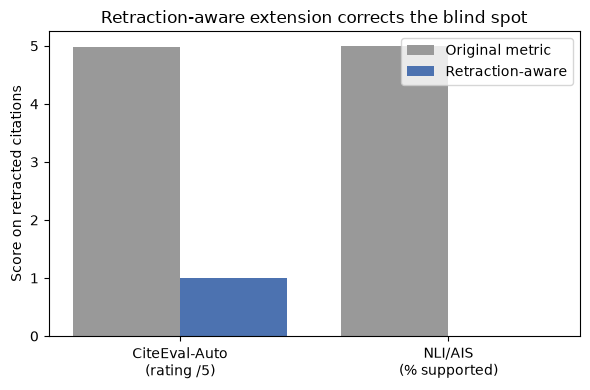

In [ ]:
# plotting the results

import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize = (6, 4))
labels = ['CiteEval-Auto\n(rating /5)', 'NLI/AIS\n(% supported)']
before = [findings['citeeval_retracted'].mean(), (findings['nli_retracted'] >= 0.5).mean() * 5]  
after  = [findings['citeeval_aware'].mean(),      (findings['nli_aware'] >= 0.5).mean() * 5]

x = range(len(labels))
ax.bar([i - 0.2 for i in x], before, width = 0.4, label = 'Original metric', color = '#A6C8E0')
ax.bar([i + 0.2 for i in x], after,  width = 0.4, label = 'Retraction-aware', color = '#2A5783')
ax.set_xticks(list(x))
ax.set_xticklabels(labels)
ax.set_ylabel('Score on retracted citations')
ax.set_title('Retraction-aware extension corrects the blind spot')
ax.legend()
plt.tight_layout()
plt.savefig('../data/final/fix_before_after.png', dpi = 150)
plt.show()